In [17]:
import kagglehub

path = kagglehub.dataset_download("norbertelter/pcb-defect-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pcb-defect-dataset' dataset.
Path to dataset files: /kaggle/input/pcb-defect-dataset


In [18]:
import os

files = os.listdir('/kaggle/input/pcb-defect-dataset')
print(files)

import os

with open(path + "/pcb-defect-dataset/data.yaml", "r") as f:
    print(f.read())

['pcb-defect-dataset']
path: ../pcb-defect-dataset
train: train
val: val
test: test

names:
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short
  4: open_circuit
  5: spurious_copper



In [19]:
import os
from pathlib import Path
path = path + "/pcb-defect-dataset"
DATASET_DIR = Path(path)

print("Dataset path:", DATASET_DIR)
print("Root files:", os.listdir(DATASET_DIR))

for split in ["train", "val", "test"]:
    split_dir = DATASET_DIR / split
    print(f"\n{split.upper()}:")
    print(os.listdir(split_dir))
    print("Images:", len(list((split_dir / "images").glob("*"))))
    print("Labels:", len(list((split_dir / "labels").glob("*"))))

Dataset path: /kaggle/input/pcb-defect-dataset/pcb-defect-dataset
Root files: ['data.yaml', 'val', 'test', 'train']

TRAIN:
['labels', 'images']
Images: 8534
Labels: 8534

VAL:
['labels', 'images']
Images: 1066
Labels: 1066

TEST:
['labels', 'images']
Images: 1068
Labels: 1068


In [20]:
class_names = {
    0: "mouse_bite",
    1: "spur",
    2: "missing_hole",
    3: "short",
    4: "open_circuit",
    5: "spurious_copper"
}

class_names

{0: 'mouse_bite',
 1: 'spur',
 2: 'missing_hole',
 3: 'short',
 4: 'open_circuit',
 5: 'spurious_copper'}

In [21]:
def plot_yolo_annotation(image_path, label_path, class_names):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w, c = image.shape
    image_with_boxes = image.copy()

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        class_id = int(parts[0])
        x_center = float(parts[1])
        y_center = float(parts[2])
        bbox_width = float(parts[3])
        bbox_height = float(parts[4])

        x_center = x_center * w
        y_center = y_center * h
        bbox_width = bbox_width * w
        bbox_height = bbox_height * h

        print("x_center_pixels:", x_center)
        print("y_center_pixels:", y_center)
        print("bbox_width_pixels:", bbox_width)
        print("bbox_height_pixels:", bbox_height)

        x_min = int(x_center - bbox_width / 2)
        y_min = int(y_center - bbox_height / 2)
        x_max = int(x_center + bbox_width / 2)
        y_max = int(y_center + bbox_height / 2)

        cv2.rectangle(
            image_with_boxes,
            (x_min, y_min),
            (x_max, y_max),
            (255, 0, 0),
            2
        )

        cv2.putText(
            image_with_boxes,
            class_names[class_id],
            (x_min, max(y_min - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1
        )

    plt.figure(figsize=(8, 8))
    plt.imshow(image_with_boxes)
    plt.axis("off")
    plt.show()

In [22]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [26]:
from pathlib import Path

fixed_yaml = f"""
path: {DATASET_DIR}

train: train/images
val: val/images
test: test/images

names:
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short
  4: open_circuit
  5: spurious_copper
"""

fixed_yaml_path = Path("/tmp/data_fixed.yaml")

with open(fixed_yaml_path, "w") as f:
    f.write(fixed_yaml)

print(fixed_yaml_path)

/tmp/data_fixed.yaml


In [27]:
with open(fixed_yaml_path, "r") as f:
    print(f.read())


path: /kaggle/input/pcb-defect-dataset/pcb-defect-dataset

train: train/images
val: val/images
test: test/images

names:
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short
  4: open_circuit
  5: spurious_copper



In [43]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(fixed_yaml_path),
    epochs=15,
    imgsz=416,
    batch=16,
    project="/tmp/results",
    name="yolov8n_smoke_test"
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tmp/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_smoke_test-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

In [44]:
best_model = YOLO("/tmp/results/yolov8n_smoke_test/weights/best.pt")

In [45]:
DATASET_DIR = Path("/kaggle/input/pcb-defect-dataset/pcb-defect-dataset")

In [46]:
import pandas as pd
from pathlib import Path

class_names = {
    0: "mouse_bite",
    1: "spur",
    2: "missing_hole",
    3: "short",
    4: "open_circuit",
    5: "spurious_copper"
}

records = []
unmatched_labels = []

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

for split in ["train", "val", "test"]:
    labels_dir = DATASET_DIR / split / "labels"
    images_dir = DATASET_DIR / split / "images"

    all_images = []
    for ext in image_extensions:
        all_images.extend(list(images_dir.rglob(f"*{ext}")))

    image_map = {img.stem: img for img in all_images}
    label_files = list(labels_dir.rglob("*.txt"))

    print(f"{split}: images found = {len(all_images)}, labels found = {len(label_files)}")

    for label_path in label_files:
        label_stem = label_path.stem

        image_path = None

        if label_stem in image_map:
            image_path = image_map[label_stem]
        else:
            alternative_stem = label_stem.replace("_256", "_600")
            if alternative_stem in image_map:
                image_path = image_map[alternative_stem]

        if image_path is None:
            unmatched_labels.append(str(label_path))
            continue

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])

            records.append({
                "split": split,
                "image_path": str(image_path),
                "label_path": str(label_path),
                "image_name": image_path.name,
                "label_name": label_path.name,
                "class_id": class_id,
                "class_name": class_names[class_id],
                "x_center": float(parts[1]),
                "y_center": float(parts[2]),
                "bbox_width": float(parts[3]),
                "bbox_height": float(parts[4])
            })

df = pd.DataFrame(records)

print("DataFrame shape:", df.shape)
print("Unmatched labels:", len(unmatched_labels))

df.head()

train: images found = 8534, labels found = 8534
val: images found = 1066, labels found = 1066
test: images found = 1068, labels found = 1068
DataFrame shape: (21664, 11)
Unmatched labels: 0


,split,image_path,label_path,image_name,label_name,class_id,class_name,x_center,y_center,bbox_width,bbox_height
0,train,/kaggle/input/pcb-defect-dataset/pcb-defect-da...,/kaggle/input/pcb-defect-dataset/pcb-defect-da...,rotation_270_light_06_mouse_bite_01_3_600.jpg,rotation_270_light_06_mouse_bite_01_3_600.txt,0,mouse_bite,0.4942,0.0441,0.0233,0.0416
1,train,/kaggle/input/pcb-defect-dataset/pcb-defect-da...,/kaggle/input/pcb-defect-dataset/pcb-defect-da...,rotation_270_light_06_mouse_bite_01_3_600.jpg,rotation_270_light_06_mouse_bite_01_3_600.txt,0,mouse_bite,0.5017,0.7687,0.0516,0.0266
2,train,/kaggle/input/pcb-defect-dataset/pcb-defect-da...,/kaggle/input/pcb-defect-dataset/pcb-defect-da...,rotation_270_light_05_spur_01_2_600.jpg,rotation_270_light_05_spur_01_2_600.txt,1,spur,0.5316,0.4734,0.0383,0.0483
3,train,/kaggle/input/pcb-defect-dataset/pcb-defect-da...,/kaggle/input/pcb-defect-dataset/pcb-defect-da...,rotation_270_light_05_spur_01_2_600.jpg,rotation_270_light_05_spur_01_2_600.txt,1,spur,0.9010,0.7463,0.0383,0.0715
4,train,/kaggle/input/pcb-defect-dataset/pcb-defect-da...,/kaggle/input/pcb-defect-dataset/pcb-defect-da...,l_light_11_spur_07_1_600.jpg,l_light_11_spur_07_1_600.txt,1,spur,0.8342,0.4983,0.0617,0.0767


In [47]:
df["bbox_area"] = df["bbox_width"] * df["bbox_height"]
df.shape
df["split"].value_counts()
df["class_name"].value_counts()

,count
class_name,
mouse_bite,3684
spurious_copper,3676
spur,3636
missing_hole,3612
open_circuit,3548
short,3508


In [48]:
sample_test = df[df["split"] == "test"].sample(1).iloc[0]

results = best_model.predict(
    source=sample_test["image_path"],
    conf=0.25,
    save=True
)


image 1/1 /kaggle/input/pcb-defect-dataset/pcb-defect-dataset/test/images/l_light_04_spur_08_3_600.jpg: 416x416 1 spur, 8.1ms
Speed: 2.7ms preprocess, 8.1ms inference, 2.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict-2


['l_light_04_spur_08_3_600.jpg']


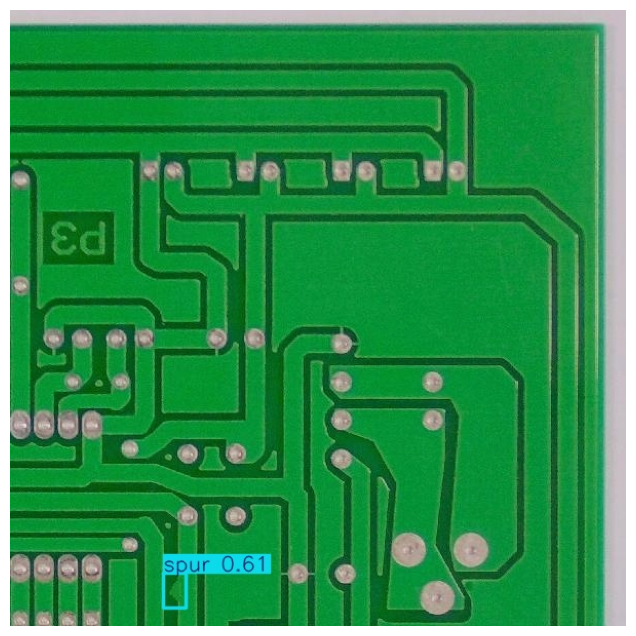

In [49]:
import os
import cv2
import matplotlib.pyplot as plt

print(os.listdir("/content/runs/detect/predict"))

pred_path = "/content/runs/detect/predict/l_light_04_spur_08_3_600.jpg"

img = cv2.imread(pred_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [50]:
best_model_path = "/tmp/results/yolov8n_smoke_test/weights/best.pt"


image 1/1 /kaggle/input/pcb-defect-dataset/pcb-defect-dataset/test/images/light_05_spurious_copper_05_1_600.jpg: 416x416 5 spurious_coppers, 7.4ms
Speed: 1.9ms preprocess, 7.4ms inference, 1.6ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /tmp/predictions/test_example

image 1/1 /kaggle/input/pcb-defect-dataset/pcb-defect-dataset/test/images/l_light_11_short_07_4_600.jpg: 416x416 1 short, 6.7ms
Speed: 1.3ms preprocess, 6.7ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /tmp/predictions/test_example

image 1/1 /kaggle/input/pcb-defect-dataset/pcb-defect-dataset/test/images/rotation_90_light_12_missing_hole_07_2_600.jpg: 416x416 1 missing_hole, 6.5ms
Speed: 1.4ms preprocess, 6.5ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /tmp/predictions/test_example

image 1/1 /kaggle/input/pcb-defect-dataset/pcb-defect-dataset/test/images/light_12_spurious_copper_07_1_600.jpg: 416x416 1 spurious_copper, 

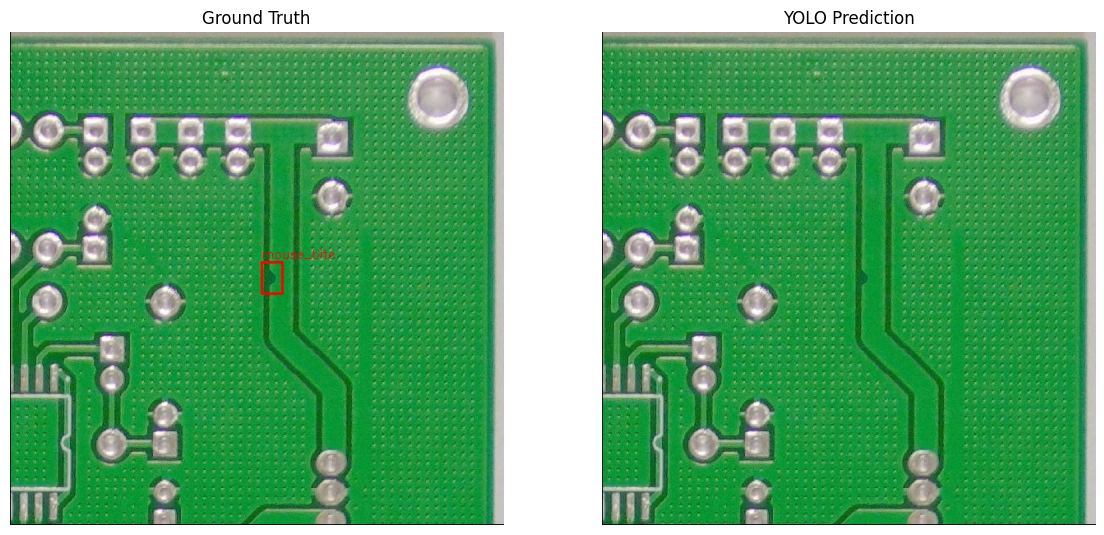

In [51]:
from pathlib import Path


def make_prediction(image_path):
    results = best_model.predict(
        source=image_path,
        conf=0.25,
        save=True,
        project="/tmp/predictions",
        name="test_example",
        exist_ok=True
    )
    return results

counter = 0
for counter in range(5):
    sample_test = df[df["split"] == "test"].sample(1).iloc[0]
    make_prediction(sample_test["image_path"])
    counter += 1

sample_test = df[df["split"] == "test"].sample(1).iloc[0]

# 1. Prediction
make_prediction(sample_test["image_path"])

pred_dir = Path("/tmp/predictions/test_example")
pred_image_path = pred_dir / Path(sample_test["image_path"]).name

# 2. Ground truth image manually
gt_image = cv2.imread(str(sample_test["image_path"]))
gt_image = cv2.cvtColor(gt_image, cv2.COLOR_BGR2RGB)

h, w, c = gt_image.shape
gt_image_with_boxes = gt_image.copy()

with open(sample_test["label_path"], "r") as f:
    lines = f.readlines()

for line in lines:
    parts = line.strip().split()

    class_id = int(parts[0])
    x_center = float(parts[1]) * w
    y_center = float(parts[2]) * h
    bbox_width = float(parts[3]) * w
    bbox_height = float(parts[4]) * h

    x_min = int(x_center - bbox_width / 2)
    y_min = int(y_center - bbox_height / 2)
    x_max = int(x_center + bbox_width / 2)
    y_max = int(y_center + bbox_height / 2)

    cv2.rectangle(gt_image_with_boxes, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
    cv2.putText(
        gt_image_with_boxes,
        class_names[class_id],
        (x_min, max(y_min - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

# 3. Prediction image
pred_image = cv2.imread(str(pred_image_path))
pred_image = cv2.cvtColor(pred_image, cv2.COLOR_BGR2RGB)

# 4. Show side by side
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(gt_image_with_boxes)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred_image)
plt.title("YOLO Prediction")
plt.axis("off")

plt.show()

In [52]:
baseline_model = YOLO("/tmp/results/yolov8n_smoke_test-2/weights/best.pt")

test_metrics = baseline_model.val(
    data=str(fixed_yaml_path),
    split="test",
    imgsz=416
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.5 ms, read: 11.8±5.4 MB/s, size: 93.9 KB)
val: Scanning /kaggle/input/pcb-defect-dataset/pcb-defect-dataset/test/labels... 829 images, 239 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1068/1068 118.1it/s 9.0s
WARNING ⚠️ val: Cache directory /kaggle/input/pcb-defect-dataset/pcb-defect-dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 7.3it/s 9.2s
                   all       1068       1662       0.97       0.93      0.971      0.497
            mouse_bite        131        262      0.971      0.907      0.955      0.482
                  spur        138        279      0.969      0.889      0.969      0.492
          missing_hole        145        283      0.983      0.986      0.99